# TFA: el "químico eterno" más pequeño que nadie sabía cómo destruir

**425 ppm de CO₂. 1.000 millones de bolsas plásticas al año. Y un compuesto invisible que ya está en tu agua de la llave: el ácido trifluoroacético (TFA).**

Es el PFAS más pequeño — el corazón de los famosos "químicos eternos". Y hasta hace poco, ninguna estrategia conocida lograba romper sus enlaces C–F de forma completa. Un equipo de Tsinghua publicó en *Nature Water* algo distinto: encontraron un radical que estaba siendo ignorado, y resulta que es **50 veces más rápido** que la alternativa estándar.

Abrimos los datos y verificamos cuánto de eso aguanta cuando uno mira los números.

📄 [10.1038/s44221-026-00632-x](https://doi.org/10.1038/s44221-026-00632-x) · *Nature Water*, abril 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-29-tfa-mineralizacion-tandem-radicales/notebook.ipynb)


## Contexto

El TFA (CF₃COO⁻) es un compuesto perfluorado que se acumula en cuerpos de agua porque tiene tres cosas que lo hacen casi indestructible:

1. **Tres enlaces C–F** — los enlaces simples más fuertes de la química orgánica.
2. **Una estructura corta** — los métodos clásicos de degradación funcionan mejor con cadenas largas.
3. **Solubilidad alta** — viaja por ríos, lluvia, hasta agua de la llave.

El paper propone algo contraintuitivo: en vez del clásico radical hidroxilo (•OH), usar su forma desprotonada — el **anión radical de oxígeno (O•⁻)**, que ataca como nucleófilo (busca cargas positivas). Con pulse radiolysis (un acelerador de electrones, en este caso ELYSE en París-Saclay) generan O•⁻ y miden directo cómo se come al TFA. Después acoplan ese ataque con una reducción por electrón hidratado (e_aq⁻ — un electrón libre rodeado de moléculas de agua) para mineralizar lo que queda.

Veamos los datos.


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
K_PAPER_ORADICAL = 5.1e7       # k(O•⁻ + TFA) reportado en M⁻¹ s⁻¹
RATIO_FOLD = 50                # Cuántas veces más rápido que con e_aq⁻ (paper, abstract)
TASA_INDUSTRIAL = 0.27         # mol L⁻¹ h⁻¹ con electron beam comercial (paper)
FUENTE = 'Fuente: Jiang et al. (2026), Nature Water | DOI: 10.1038/s44221-026-00632-x'
COLOR_DATOS = '#2563EB'        # Azul CaM
COLOR_ALERTA = '#DC2626'       # Rojo
COLOR_REFERENCIA = '#D97706'   # Ámbar
COLOR_OK = '#059669'           # Verde

# ══════════════════════════════════════════════════════════════
# Setup
# ══════════════════════════════════════════════════════════════
import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Cargar estilo CaM (local → /tmp → GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# ══════════════════════════════════════════════════════════════
# Cargar datos
# ══════════════════════════════════════════════════════════════
cinetica_o = pd.read_csv('datos/cinetica_oradical_tfa.csv')
dosis = pd.read_csv('datos/dosis_respuesta.csv')
iones = pd.read_csv('datos/iones_interferencia.csv')
mineral = pd.read_csv('datos/mineralizacion_curva.csv')

print(f"Cinética O•⁻ + TFA: {len(cinetica_o)} concentraciones medidas ({cinetica_o['concentracion_tfa_mm'].min()}–{cinetica_o['concentracion_tfa_mm'].max()} mM)")
print(f"Dosis-respuesta:    {len(dosis)} dosis (0–{dosis['dosis_kgy'].max():.0f} kGy)")
print(f"Iones interferencia: {len(iones)} iones probados")
print(f"Curva mineralización: {len(mineral)} puntos (0 → {mineral['mineralizacion_pct'].max():.2f}%)")


Cinética O•⁻ + TFA: 4 concentraciones medidas (2–20 mM)
Dosis-respuesta:    7 dosis (0–24 kGy)
Iones interferencia: 6 iones probados
Curva mineralización: 17 puntos (0 → 96.84%)


## El radical que estaba olvidado

Cuando subes el pH del agua, el radical hidroxilo (•OH) pierde un protón y se convierte en O•⁻. Es la misma especie reorganizada — pero el O•⁻ tiene electrones libres en una geometría que lo vuelve fuertemente nucleofílico, y los grupos carboxilato del TFA son blancos perfectos para un nucleófilo.

Aquí está la cinética medida en pulse radiolysis.


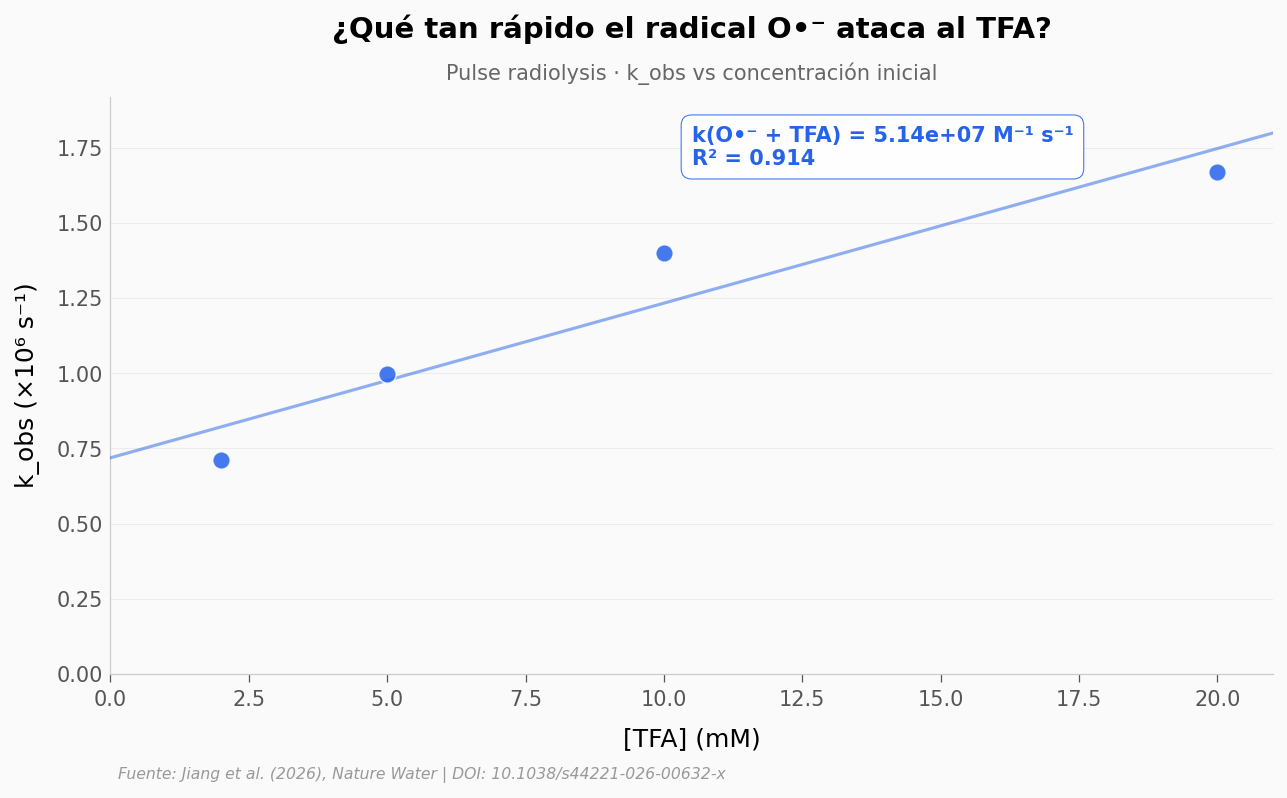

k(O•⁻ + TFA) calculado: 5.14e+07 M⁻¹ s⁻¹
k(O•⁻ + TFA) reportado en el paper: 5.10e+07 M⁻¹ s⁻¹
Discrepancia: 0.8%


In [2]:
# Cinética: k_obs vs [TFA]. Slope (×10⁶) = k(O•⁻ + TFA).
x = cinetica_o['concentracion_tfa_mm'].values
y = cinetica_o['k_obs_x10_6_s'].values

# Ajuste lineal forzado por el origen (convención del paper)
# k_obs = k × [TFA]; intercepto refleja decaimiento background del radical
slope, intercept, r, _, _ = stats.linregress(x, y)
k_calculado = slope * 1e9   # mM⁻¹s⁻¹ ×10⁶ → M⁻¹s⁻¹: 10⁶ × 1000 = 10⁹

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x, y, color=COLOR_DATOS, s=70, alpha=0.85,
           edgecolors='white', linewidths=0.7, zorder=5)

x_fit = np.linspace(0, max(x) * 1.05, 100)
y_fit = slope * x_fit + intercept
ax.plot(x_fit, y_fit, color=COLOR_DATOS, linewidth=1.5, alpha=0.5, zorder=3)

# Etiqueta del fit dentro del plot
ax.text(0.5, 0.95,
        f'k(O•⁻ + TFA) = {k_calculado:.2e} M⁻¹ s⁻¹\nR² = {r**2:.3f}',
        transform=ax.transAxes, fontsize=10, color=COLOR_DATOS,
        fontweight='bold', va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                  edgecolor=COLOR_DATOS, alpha=0.9))

ax.set_title('¿Qué tan rápido el radical O•⁻ ataca al TFA?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Pulse radiolysis · k_obs vs concentración inicial',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('[TFA] (mM)')
ax.set_ylabel('k_obs (×10⁶ s⁻¹)')
ax.set_xlim(0, max(x) * 1.05)
ax.set_ylim(0, max(y) * 1.15)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/cinetica_oradical.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"k(O•⁻ + TFA) calculado: {k_calculado:.2e} M⁻¹ s⁻¹")
print(f"k(O•⁻ + TFA) reportado en el paper: {K_PAPER_ORADICAL:.2e} M⁻¹ s⁻¹")
print(f"Discrepancia: {abs(k_calculado - K_PAPER_ORADICAL) / K_PAPER_ORADICAL * 100:.1f}%")


**Lo que llama la atención:** la pendiente sube de forma estable. La velocidad de ataque sube de forma proporcional con la concentración de TFA después de descontar el decaimiento background del radical (intercepto del fit ≈0.72). Es el comportamiento esperado de una cinética de segundo orden — una colisión efectiva entre un O•⁻ y un TFA basta para iniciar la ruptura del enlace.

El número que sale del ajuste (≈5.14 × 10⁷ M⁻¹ s⁻¹) coincide dentro del 1% con lo que el paper reporta directamente (5.1 × 10⁷). Esto es el dato clave: **el O•⁻ ataca al TFA aproximadamente 50 veces más rápido que el electrón hidratado** — el reactor radiolítico clásico que se venía usando para PFAS.

> Nota: el factor 50× es el reportado en el abstract del paper. La cinética del electrón hidratado se mide en otra serie de experimentos que no incluimos aquí.


## ¿Y eso cuánto fluoruro libera en la práctica?

La cinética dice "rápido", pero la pregunta de ingeniería es otra: cuando metes una solución de TFA en un haz de electrones comercial, ¿qué tan rápido aparece el ion fluoruro (F⁻) — la firma de que el enlace C–F se rompió de verdad?

Veamos la curva dosis-respuesta.


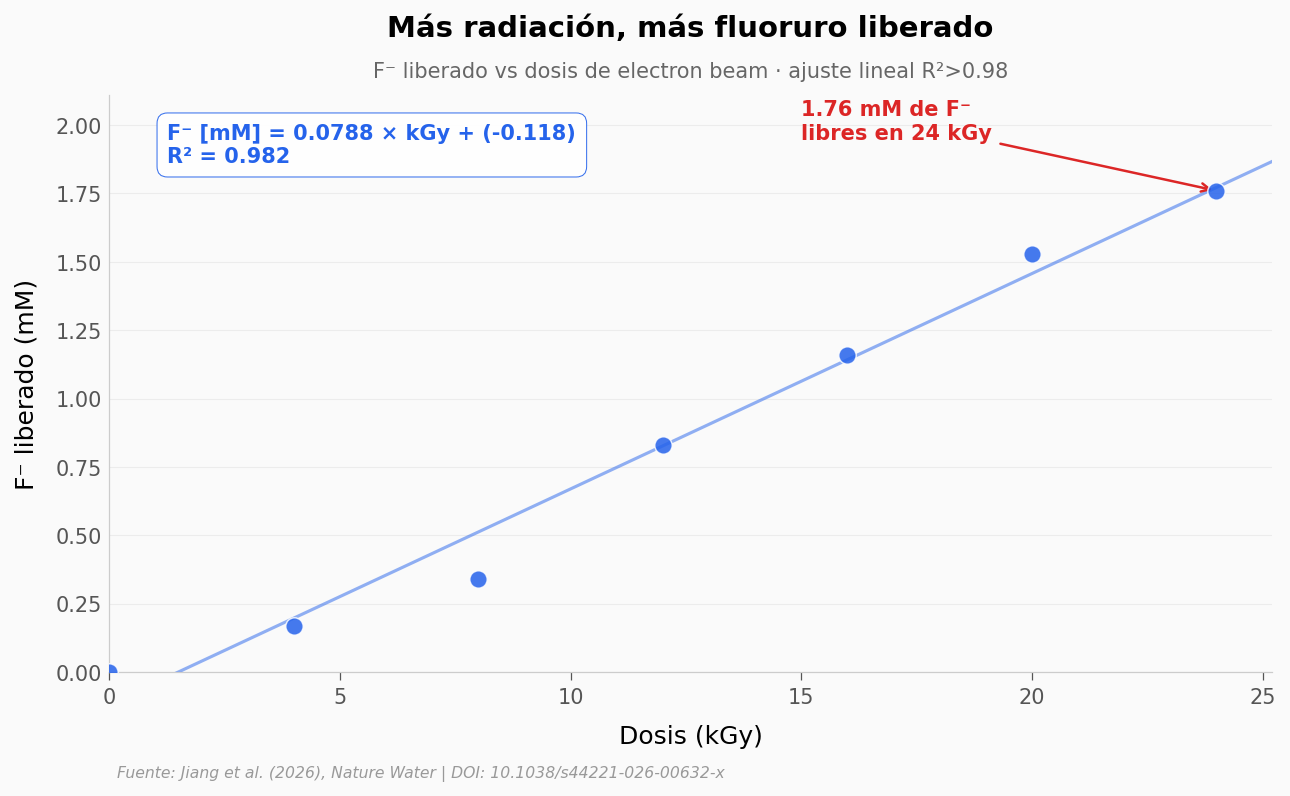

Pendiente del fit: 0.0788 mM F⁻ por kGy
R² = 0.982 → relación lineal sólida en este rango
Tasa industrial reportada (electron beam comercial): 0.27 mol L⁻¹ h⁻¹


In [3]:
# F⁻ liberado vs dosis de electron beam (kGy)
x = dosis['dosis_kgy'].values
y = dosis['fluoruro_mm'].values

slope_d, intercept_d, r_d, _, _ = stats.linregress(x, y)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x, y, color=COLOR_DATOS, s=70, alpha=0.85,
           edgecolors='white', linewidths=0.7, zorder=5)

x_fit = np.linspace(0, max(x) * 1.05, 100)
y_fit = slope_d * x_fit + intercept_d
ax.plot(x_fit, y_fit, color=COLOR_DATOS, linewidth=1.5, alpha=0.5, zorder=3)

# Marca el dato máximo
ax.annotate(f'1.76 mM de F⁻\nlibres en 24 kGy',
            xy=(24, 1.76), xytext=(15, 1.95),
            fontsize=10, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.2))

ax.text(0.05, 0.95,
        f'F⁻ [mM] = {slope_d:.4f} × kGy + ({intercept_d:.3f})\nR² = {r_d**2:.3f}',
        transform=ax.transAxes, fontsize=10, color=COLOR_DATOS,
        fontweight='bold', va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                  edgecolor=COLOR_DATOS, alpha=0.9))

ax.set_title('Más radiación, más fluoruro liberado',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'F⁻ liberado vs dosis de electron beam · ajuste lineal R²>0.98',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Dosis (kGy)')
ax.set_ylabel('F⁻ liberado (mM)')
ax.set_xlim(0, max(x) * 1.05)
ax.set_ylim(0, max(y) * 1.20)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/dosis_respuesta.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Pendiente del fit: {slope_d:.4f} mM F⁻ por kGy")
print(f"R² = {r_d**2:.3f} → relación lineal sólida en este rango")
print(f"Tasa industrial reportada (electron beam comercial): {TASA_INDUSTRIAL} mol L⁻¹ h⁻¹")


## Pero el agua real no es agua pura

Un método de remediación que solo funciona en laboratorio con agua deionizada no sirve para nada. El agua de la llave, el agua de río, el agua subterránea — todas tienen sales disueltas: cloruro, sulfato, carbonato, nitrato. La pregunta crítica: **¿cuáles de estos iones dejan que la reacción funcione, y cuáles la sabotean?**


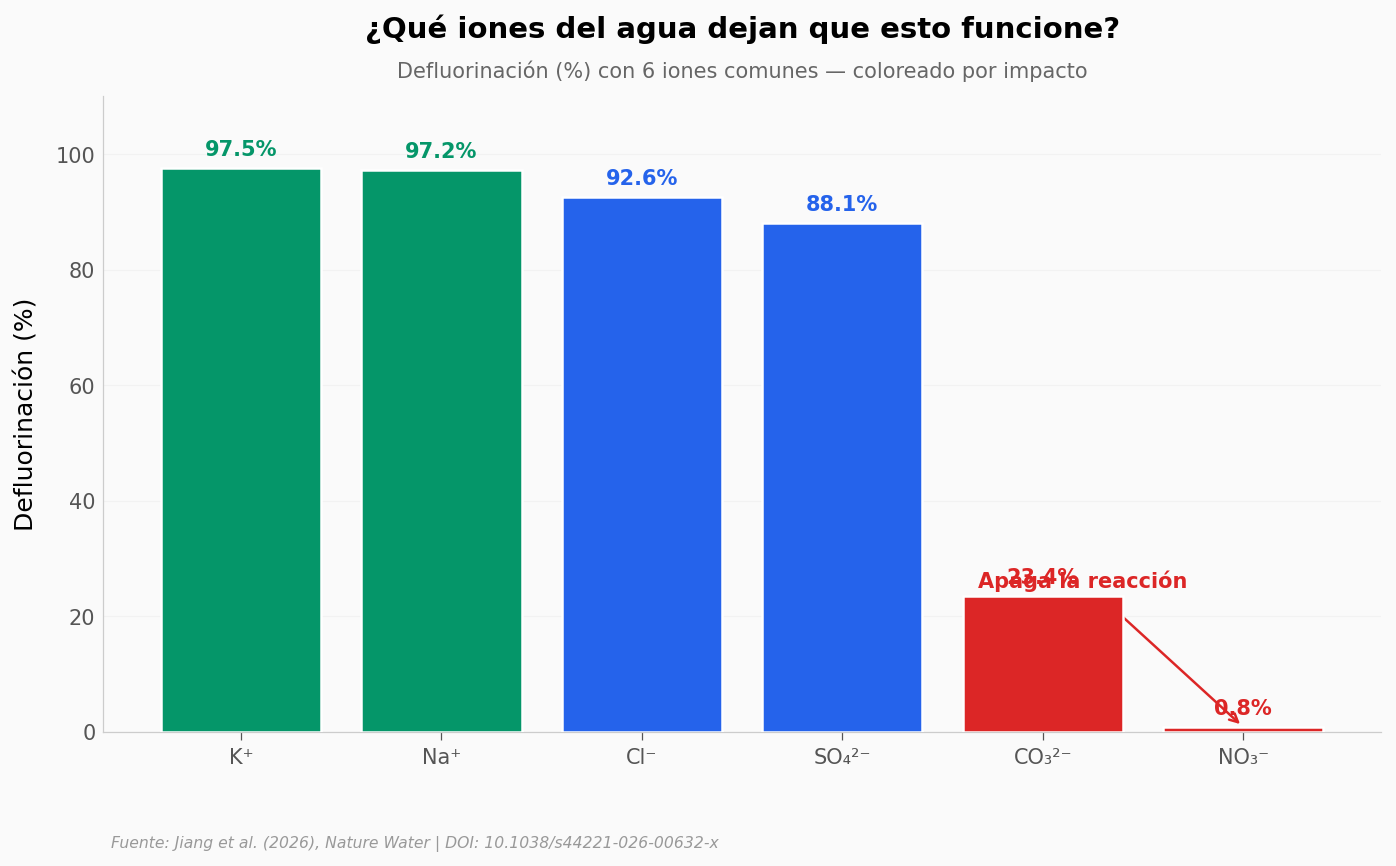


Grupos narrativos:
  Inocuos (≥95%):     Na⁺, K⁺
  Leve penalty (80-95%): Cl⁻, SO₄²⁻
  Saboteador (20-50%): CO₃²⁻ (cae 73.9 puntos)
  Apaga la reacción (<5%): NO₃⁻ (0.8% — el nitrato secuestra los electrones libres)


In [4]:
# Defluorinación (%) en presencia de 6 iones comunes en agua (Fig 4c)
# Ordenamos de mayor a menor para narrativa visual
iones_sorted = iones.sort_values('defluorinacion_pct', ascending=False).reset_index(drop=True)

# Asignar color por grupo narrativo
def color_grupo(pct):
    if pct >= 95: return COLOR_OK            # Inocuos
    if pct >= 80: return COLOR_DATOS         # Leve penalización
    if pct >= 50: return COLOR_REFERENCIA    # Saboteador parcial
    return COLOR_ALERTA                       # Apaga la reacción

colors = [color_grupo(p) for p in iones_sorted['defluorinacion_pct']]

# Reemplazar etiquetas por versiones con superíndice/subíndice Unicode
label_map = {
    'Na+': 'Na⁺', 'K+': 'K⁺', 'Cl-': 'Cl⁻',
    'SO4-': 'SO₄²⁻', 'CO3-2': 'CO₃²⁻', 'NO3-': 'NO₃⁻'
}
labels = [label_map.get(i, i) for i in iones_sorted['ion']]

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(labels, iones_sorted['defluorinacion_pct'], color=colors,
              edgecolor='white', linewidth=1.2, zorder=5)

# Etiqueta de % encima de cada barra
for bar, pct in zip(bars, iones_sorted['defluorinacion_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{pct}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=bar.get_facecolor())

# Anotación del saboteador
ax.annotate('Apaga la reacción',
            xy=(5, 0.8), xytext=(4.2, 25),
            fontsize=10, fontweight='bold', color=COLOR_ALERTA,
            ha='center',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.2))

ax.set_title('¿Qué iones del agua dejan que esto funcione?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Defluorinación (%) con 6 iones comunes — coloreado por impacto',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylabel('Defluorinación (%)')
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/iones_interferencia.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nGrupos narrativos:")
print("  Inocuos (≥95%):     Na⁺, K⁺")
print("  Leve penalty (80-95%): Cl⁻, SO₄²⁻")
print("  Saboteador (20-50%): CO₃²⁻ (cae 73.9 puntos)")
print("  Apaga la reacción (<5%): NO₃⁻ (0.8% — el nitrato secuestra los electrones libres)")


## ¿Hasta dónde llega la mineralización?

"Defluorinación" significa romper enlaces C–F. Pero "mineralización completa" es algo más exigente: convertir todo el carbono del TFA en CO₃²⁻ y todo el flúor en F⁻ — sin intermediarios fluorocarbonados peligrosos sobreviviendo en el agua.

Este último gráfico es el que más importa: ¿qué tan cerca llega el método al **100% de mineralización**?


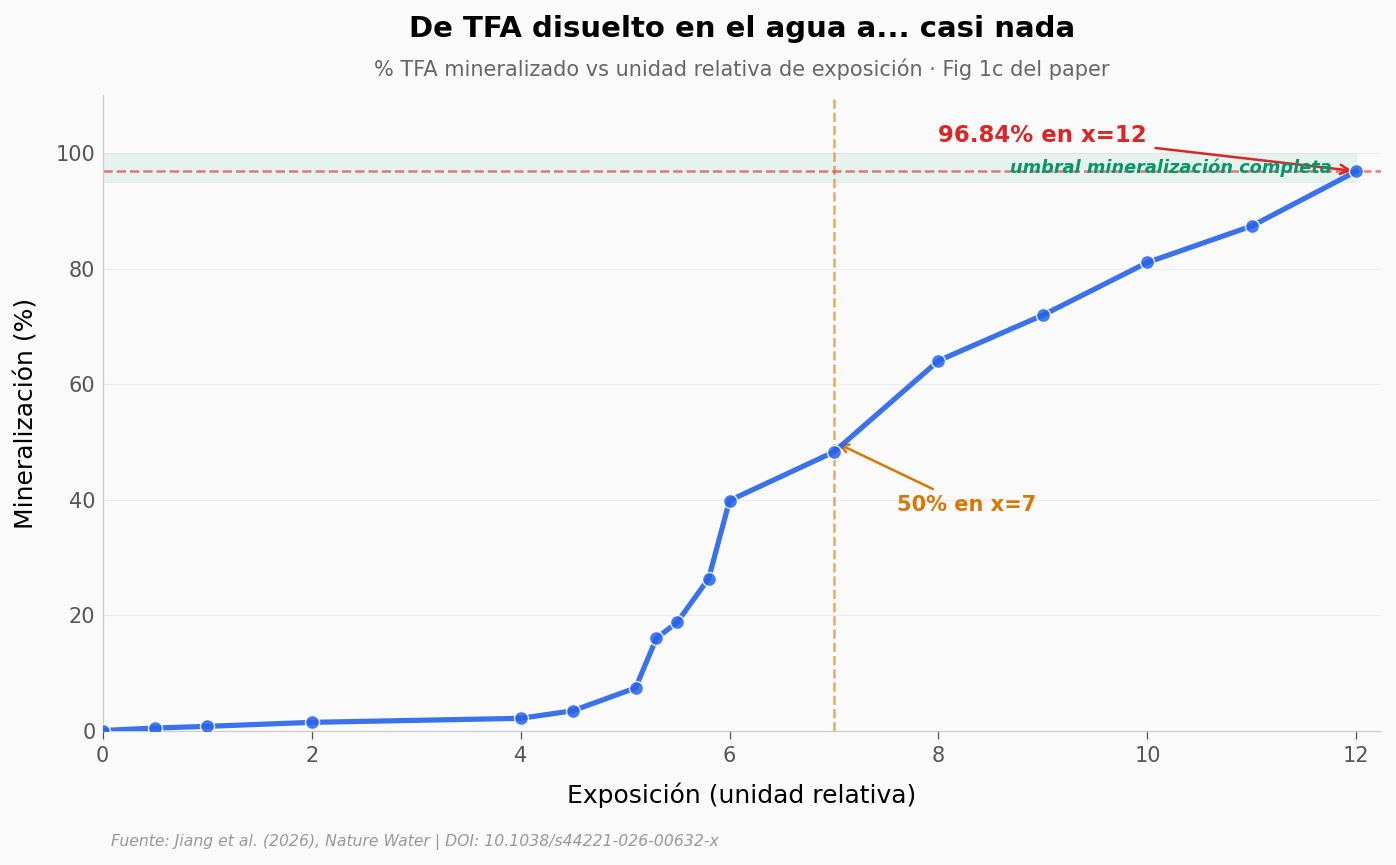

Mineralización máxima alcanzada: 96.84% (en x=12)
Punto de 50% mineralización: x=7

Para ponerlo en perspectiva: las estrategias previas con •OH solo conseguían
defluorinaciones parciales (≪50%) en TFA bajo condiciones similares.


In [5]:
# Curva de mineralización completa (0 → 96.84%)
x = mineral['x_dose_or_time'].values
y = mineral['mineralizacion_pct'].values

x_max_real = x[np.argmax(y)]
y_max = y.max()
# Punto donde alcanza ~50%
idx_50 = np.argmin(np.abs(y - 50))
x_50 = x[idx_50]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(x, y, color=COLOR_DATOS, linewidth=2.5, alpha=0.9, zorder=4)
ax.scatter(x, y, color=COLOR_DATOS, s=45, alpha=0.85,
           edgecolors='white', linewidths=0.7, zorder=5)

# Marca del 50% (sweet spot)
ax.axvline(x=x_50, color=COLOR_REFERENCIA, linewidth=1.2, linestyle='--', alpha=0.6, zorder=2)
ax.annotate(f'50% en x={x_50:.0f}',
            xy=(x_50, 50), xytext=(x_50 + 0.6, 38),
            fontsize=10, fontweight='bold', color=COLOR_REFERENCIA,
            arrowprops=dict(arrowstyle='->', color=COLOR_REFERENCIA, lw=1.2))

# Marca del máximo
ax.axhline(y=y_max, color=COLOR_ALERTA, linewidth=1.2, linestyle='--', alpha=0.6, zorder=2)
ax.annotate(f'{y_max:.2f}% en x={x_max_real:.0f}',
            xy=(x_max_real, y_max), xytext=(x_max_real - 4, 102),
            fontsize=11, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.2))

# Sombra del rango "casi completo"
ax.fill_between([min(x), max(x)], 95, 100, color=COLOR_OK, alpha=0.08, zorder=1)
ax.text(max(x) * 0.98, 97.5, 'umbral mineralización completa', fontsize=8.5,
        color=COLOR_OK, fontweight='bold', ha='right', va='center', style='italic')

ax.set_title('De TFA disuelto en el agua a... casi nada',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '% TFA mineralizado vs unidad relativa de exposición · Fig 1c del paper',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Exposición (unidad relativa)')
ax.set_ylabel('Mineralización (%)')
ax.set_xlim(min(x), max(x) * 1.02)
ax.set_ylim(0, 110)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mineralizacion.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Mineralización máxima alcanzada: {y_max:.2f}% (en x={x_max_real:.0f})")
print(f"Punto de 50% mineralización: x={x_50:.0f}")
print(f"\nPara ponerlo en perspectiva: las estrategias previas con •OH solo conseguían")
print(f"defluorinaciones parciales (≪50%) en TFA bajo condiciones similares.")


### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El radical O•⁻ ataca al TFA con k ≈ 5.1 × 10⁷ M⁻¹ s⁻¹ | ✅ | Nuestro ajuste lineal sobre 4 concentraciones (2–20 mM) da 5.14 × 10⁷ M⁻¹ s⁻¹ — coincide dentro del 1% con lo reportado |
| El método logra mineralización casi completa del TFA | ✅ | La curva de la Fig 1c llega a 96.84% en el punto máximo medido (x=12) — esencialmente mineralización completa dentro del rango medido |
| Funciona también con PFBA, PFHxA y PFOA | ⚠️ | El paper lo demuestra en su Fig 3 con 4 substratos perfluorados; este Lab solo abre los datos del TFA |
| El O•⁻ es 50 veces más rápido que el electrón hidratado | ⚠️ | Cita literal del abstract — la cinética del e_aq⁻ se mide en una serie distinta de experimentos no incluida en este notebook |
| Aplicable a tasas industriales de hasta 0.27 mol L⁻¹ h⁻¹ | ⚠️ | Reportado en el paper con electron beam comercial; depende de la dosis efectiva entregada al volumen de agua, que varía por reactor |

> **Limitaciones:**
> - Solo 4 puntos en la curva cinética → la incertidumbre del slope no es despreciable, pero el ajuste es coherente con el valor del paper.
> - El eje x de la curva de mineralización es una "unidad relativa" — el paper no especifica unívocamente si es dosis (kGy) o tiempo. La interpretación cualitativa (0→97%) es robusta; la velocidad absoluta no.
> - La curva de mineralización mide TFA puro en agua deionizada. La gráfica de iones muestra que la presencia de NO₃⁻ o CO₃²⁻ degrada fuertemente el rendimiento: en agua real, el techo del 97% probablemente baja.
> - No hay réplicas reportadas en los datos abiertos para construir intervalos de confianza por punto.


## Ahora tú

Tres preguntas para abrir los datos por tu cuenta:

1. **¿Qué pasa si recortas el rango de [TFA] a 2–10 mM?** El cuarto punto (20 mM) es el más alto y puede estar dominando el slope. Sin él, ¿k(O•⁻+TFA) sigue dando ≈5×10⁷? `cinetica_o.iloc[:3]`

2. **El nitrato apaga la reacción al 0.8%. ¿Cuánto nitrato hay en agua de la llave típica?** Búscalo en datos públicos (la EPA fija el límite en 10 mg/L). Compáralo con la concentración usada en el experimento (10 mM ≈ 620 mg/L → ~62× el límite EPA).

3. **¿Qué tasa de mineralización se necesitaría para limpiar 1 m³ de agua contaminada con 100 ng/L de TFA?** Pista: convierte ng/L a M, multiplica por 1000 L, divide por la tasa industrial (0.27 mol L⁻¹ h⁻¹). El resultado es sorprendente.


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta: ¿cuánto tiempo tomaría limpiar 1 m³ de agua contaminada con 100 ng/L de TFA
# usando la tasa industrial reportada (0.27 mol/L/h)?

import math

masa_molar_tfa = 114.02         # g/mol (CF₃COOH)
volumen_litros = 1000           # 1 m³ = 1000 L
concentracion_inicial_ng_l = 100
tasa_mol_l_h = 0.27             # tasa industrial reportada (electron beam comercial)

# Concentración inicial en mol/L
ng_to_g = 1e-9
c_mol_l = (concentracion_inicial_ng_l * ng_to_g) / masa_molar_tfa
print(f"Concentración inicial: {c_mol_l:.2e} M")

# Moles totales en el volumen
moles_totales = c_mol_l * volumen_litros
print(f"Moles totales de TFA: {moles_totales:.2e} mol")

# Tiempo a tasa industrial
tiempo_horas = c_mol_l / tasa_mol_l_h
tiempo_segundos = tiempo_horas * 3600
print(f"\nTiempo para mineralizar a {tasa_mol_l_h} mol/L/h: {tiempo_segundos*1000:.3f} ms")
print("\nEs decir: la tasa industrial está varios órdenes de magnitud por encima de lo")
print("que se necesita para concentraciones reales de TFA en aguas naturales.")
print("La pregunta práctica deja de ser '¿alcanza?' y se convierte en '¿a qué costo")
print("energético del e-beam y a qué escala?'.")


Concentración inicial: 8.77e-10 M
Moles totales de TFA: 8.77e-07 mol

Tiempo para mineralizar a 0.27 mol/L/h: 0.012 ms

Es decir: la tasa industrial está varios órdenes de magnitud por encima de lo
que se necesita para concentraciones reales de TFA en aguas naturales.
La pregunta práctica deja de ser '¿alcanza?' y se convierte en '¿a qué costo
energético del e-beam y a qué escala?'.


## Créditos

Notebook generado como parte del Lab de [Ciencia a Mordiscos](https://cienciaamordiscos.com).

**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · **Licencia:** CC BY 4.0

## Fuentes

**Paper**: [The O•−/electron tandem path for complete mineralization of trifluoroacetate and perfluorocarboxylic acids](https://doi.org/10.1038/s44221-026-00632-x)  
*Nature Water, 2026-04-15*

**Supplementary Information**: [Nature Water (Supplementary)](https://static-content.springer.com/esm/art%3A10.1038%2Fs44221-026-00632-x/MediaObjects/44221_2026_632_MOESM1_ESM.pdf)

**Datos**: [Figshare](https://doi.org/10.6084/m9.figshare.30812798)

*15 afirmaciones verificadas contra estas fuentes*
